# 🚀 E-Commerce Retail Analysis — Online Retail Dataset
## Data Analytics Project

Notebook ini dibuat untuk melakukan analisis data e-commerce menggunakan dataset **Online_Retail.xlsx** dengan tahapan analisis yang serupa dengan notebook referensi.

---
### Tahapan Analisis:
1. Import Libraries
2. Load Data
3. Data Exploration
4. Data Cleaning
5. Sales Analysis
6. Visualisasi
7. Business Insight
8. Customer Lifetime Value (CLV)


## Cell 1 — Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

plt.style.use("ggplot")
sns.set_palette("Set2")

pd.set_option("display.max_columns", None)


## Cell 2 — Load Data

In [2]:
# Load dataset
df_raw = pd.read_excel("Online_Retail.xlsx")

print("Dataset berhasil dimuat!")
print(f"Jumlah baris : {df_raw.shape[0]:,}")
print(f"Jumlah kolom : {df_raw.shape[1]}")

df_raw.head()


Dataset berhasil dimuat!
Jumlah baris : 541,909
Jumlah kolom : 8


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


## Cell 3 — Step 1: Data Exploration

In [3]:
print("=== INFO DATASET ===")
df_raw.info()


=== INFO DATASET ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [4]:
print("=== STATISTIK DESKRIPTIF ===")
df_raw.describe().round(2)


=== STATISTIK DESKRIPTIF ===


,Quantity,UnitPrice,CustomerID
count,541909.00,541909.00,406829.00
mean,9.55,4.61,15287.69
std,218.08,96.76,1713.60
min,-80995.00,-11062.06,12346.00
25%,1.00,1.25,13953.00
50%,3.00,2.08,15152.00
75%,10.00,4.13,16791.00
max,80995.00,38970.00,18287.00


In [5]:
print("=== MISSING VALUES ===")

missing = df_raw.isnull().sum()
pct = (missing / len(df_raw) * 100).round(2)

pd.DataFrame({
    "Missing Count": missing,
    "Missing Percentage": pct
}).sort_values(by="Missing Count", ascending=False)


=== MISSING VALUES ===


,Missing Count,Missing Percentage
CustomerID,135080,24.93
Description,1454,0.27
InvoiceNo,0,0.00
StockCode,0,0.00
Quantity,0,0.00
InvoiceDate,0,0.00
UnitPrice,0,0.00
Country,0,0.00


In [6]:
print("=== UNIQUE VALUE TIAP KOLOM ===")

for col in df_raw.columns:
    print(f"{col}: {df_raw[col].nunique()} unique values")


=== UNIQUE VALUE TIAP KOLOM ===
InvoiceNo: 25900 unique values
StockCode: 4070 unique values
Description: 4223 unique values
Quantity: 722 unique values
InvoiceDate: 23260 unique values
UnitPrice: 1630 unique values
CustomerID: 4372 unique values
Country: 38 unique values


## Cell 4 — Step 2: Data Cleaning

In [7]:
df = df_raw.copy()

# Menghapus data tanpa CustomerID
df = df.dropna(subset=["CustomerID"])

# Menghapus transaksi return/cancel
df = df[~df["InvoiceNo"].astype(str).str.startswith("C")]

# Menghapus quantity negatif atau nol
df = df[df["Quantity"] > 0]

# Menghapus harga negatif atau nol
df = df[df["UnitPrice"] > 0]

# Konversi tipe data
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

# Membuat kolom TotalSales
df["TotalSales"] = df["Quantity"] * df["UnitPrice"]

# Membuat fitur tambahan
df["Year"] = df["InvoiceDate"].dt.year
df["Month"] = df["InvoiceDate"].dt.month
df["MonthName"] = df["InvoiceDate"].dt.strftime("%b")
df["Day"] = df["InvoiceDate"].dt.day
df["Hour"] = df["InvoiceDate"].dt.hour

print("Ukuran dataset setelah cleaning:", df.shape)

df.head()


Ukuran dataset setelah cleaning: (397884, 14)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalSales,Year,Month,MonthName,Day,Hour
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,2010,12,Dec,1,8
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,Dec,1,8
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,2010,12,Dec,1,8
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,Dec,1,8
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,Dec,1,8


## Cell 5 — Step 3: Sales Analysis
### KPI Summary


In [8]:
total_sales = df["TotalSales"].sum()
total_orders = df["InvoiceNo"].nunique()
total_customers = df["CustomerID"].nunique()
avg_order_value = df.groupby("InvoiceNo")["TotalSales"].sum().mean()

print("=== KPI SUMMARY ===")
print(f"Total Sales       : ${total_sales:,.2f}")
print(f"Total Orders      : {total_orders:,}")
print(f"Total Customers   : {total_customers:,}")
print(f"Average Order Val.: ${avg_order_value:,.2f}")


=== KPI SUMMARY ===
Total Sales       : $8,911,407.90
Total Orders      : 18,532
Total Customers   : 4,338
Average Order Val.: $480.87


### Sales by Country

In [9]:
sales_by_country = (
    df.groupby("Country")
      .agg(
          Total_Sales=("TotalSales", "sum"),
          Total_Orders=("InvoiceNo", "nunique"),
          Total_Customers=("CustomerID", "nunique")
      )
      .sort_values(by="Total_Sales", ascending=False)
)

sales_by_country.head(10)


,Total_Sales,Total_Orders,Total_Customers
Country,,,
United Kingdom,7308391.554,16646,3920
Netherlands,285446.340,94,9
EIRE,265545.900,260,3
Germany,228867.140,457,94
France,209024.050,389,87
Australia,138521.310,57,9
Spain,61577.110,90,30
Switzerland,56443.950,51,21
Belgium,41196.340,98,25


### Top Selling Products

In [10]:
top_products = (
    df.groupby("Description")
      .agg(
          Total_Quantity=("Quantity", "sum"),
          Total_Sales=("TotalSales", "sum")
      )
      .sort_values(by="Total_Sales", ascending=False)
)

top_products.head(10)


,Total_Quantity,Total_Sales
Description,,
"PAPER CRAFT , LITTLE BIRDIE",80995,168469.60
REGENCY CAKESTAND 3 TIER,12402,142592.95
WHITE HANGING HEART T-LIGHT HOLDER,36725,100448.15
JUMBO BAG RED RETROSPOT,46181,85220.78
MEDIUM CERAMIC TOP STORAGE JAR,77916,81416.73
POSTAGE,3120,77803.96
PARTY BUNTING,15291,68844.33
ASSORTED COLOUR BIRD ORNAMENT,35362,56580.34
Manual,7173,53779.93


### Monthly Sales Trend

In [11]:
monthly_sales = (
    df.groupby(["Year", "Month"])["TotalSales"]
      .sum()
      .reset_index()
)

monthly_sales


,Year,Month,TotalSales
0,2010,12,572713.890
1,2011,1,569445.040
2,2011,2,447137.350
3,2011,3,595500.760
4,2011,4,469200.361
5,2011,5,678594.560
6,2011,6,661213.690
7,2011,7,600091.011
8,2011,8,645343.900
9,2011,9,952838.382


## Cell 6 — Step 4: Visualisasi
### Dashboard Visualisasi


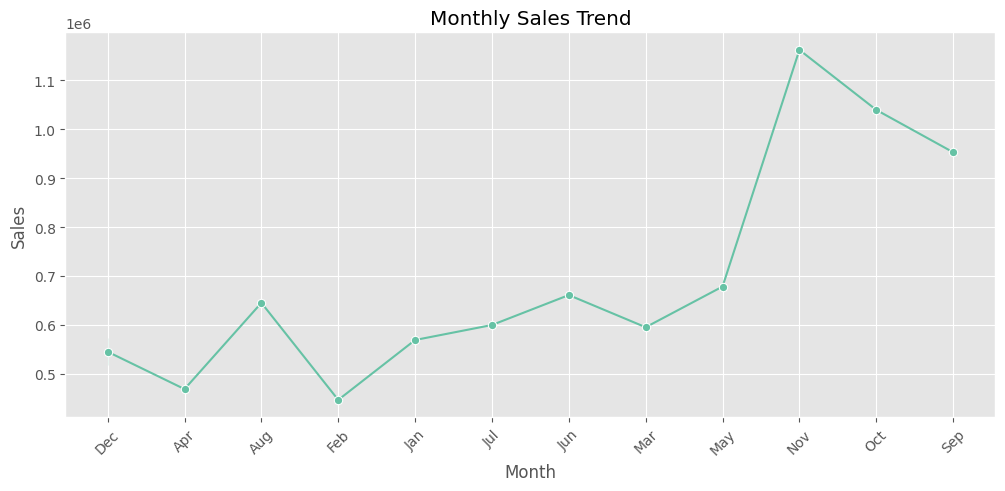

In [12]:
# Monthly Sales Trend
monthly_plot = (
    df.groupby(["Year", "MonthName"])["TotalSales"]
      .sum()
      .reset_index()
)

plt.figure(figsize=(12,5))
sns.lineplot(data=monthly_plot, x="MonthName", y="TotalSales", marker="o")

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.xticks(rotation=45)

plt.show()


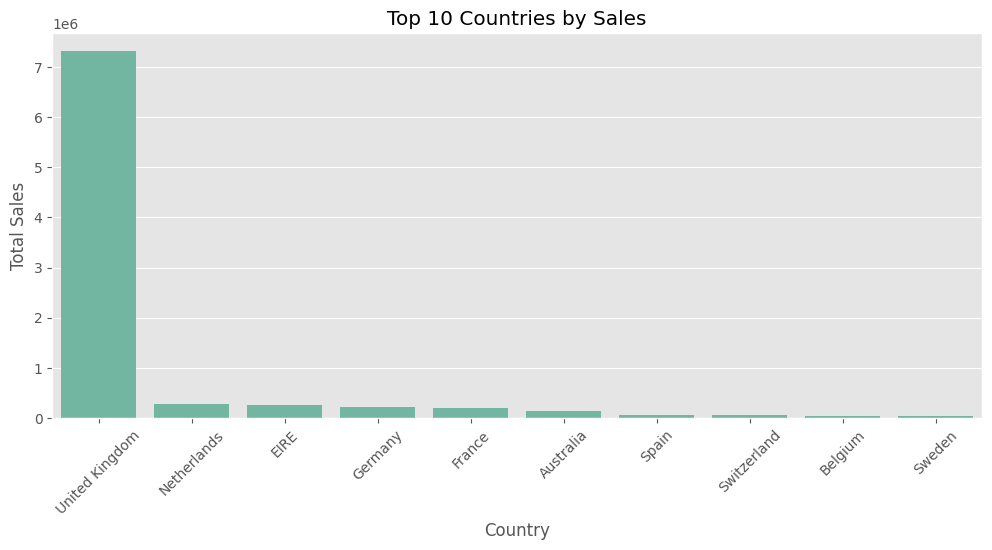

In [13]:
# Top 10 Countries by Sales
top_country = sales_by_country.head(10).reset_index()

plt.figure(figsize=(12,5))
sns.barplot(data=top_country, x="Country", y="Total_Sales")

plt.title("Top 10 Countries by Sales")
plt.xlabel("Country")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)

plt.show()


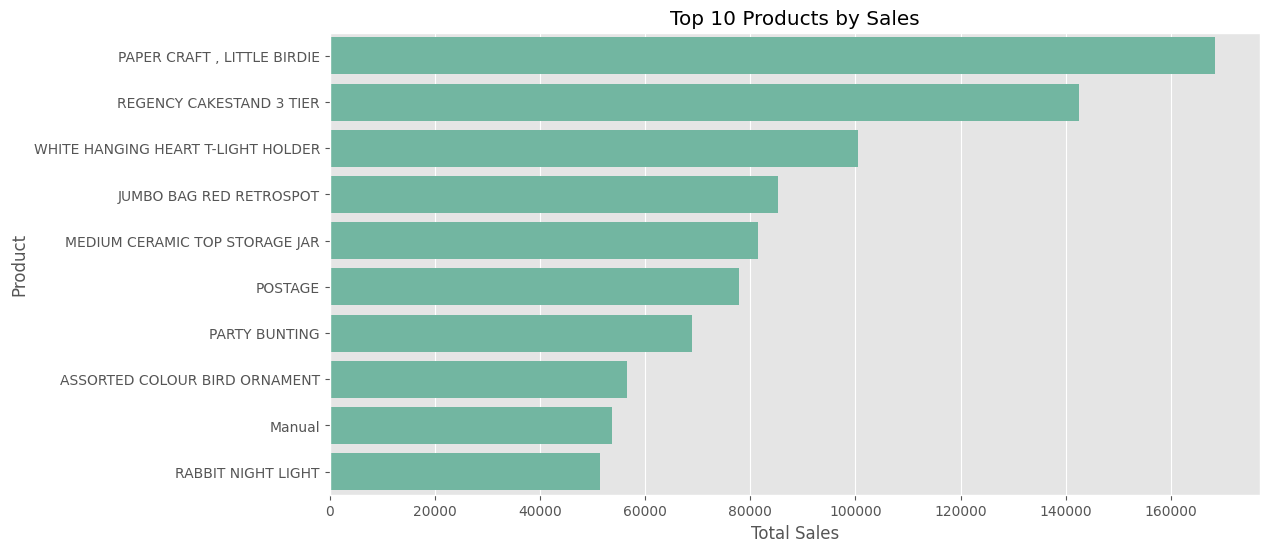

In [14]:
# Top 10 Products by Sales
top_products_plot = top_products.head(10).reset_index()

plt.figure(figsize=(12,6))
sns.barplot(data=top_products_plot, x="Total_Sales", y="Description")

plt.title("Top 10 Products by Sales")
plt.xlabel("Total Sales")
plt.ylabel("Product")

plt.show()


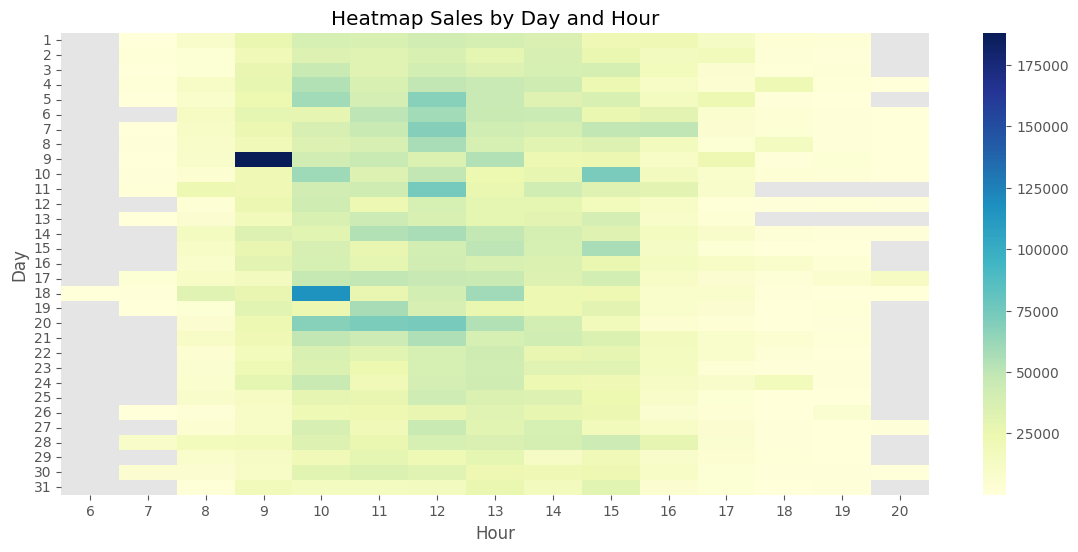

In [15]:
# Heatmap transaksi berdasarkan jam dan hari
heatmap_data = df.pivot_table(
    values="TotalSales",
    index="Day",
    columns="Hour",
    aggfunc="sum"
)

plt.figure(figsize=(14,6))
sns.heatmap(heatmap_data, cmap="YlGnBu")

plt.title("Heatmap Sales by Day and Hour")

plt.show()


## Cell 7 — Step 5: Business Insight
> Insight bisnis berdasarkan hasil analisis data


In [16]:
# Insight otomatis sederhana

top_country_name = sales_by_country.index[0]
top_country_sales = sales_by_country.iloc[0]["Total_Sales"]

top_product_name = top_products.index[0]
top_product_sales = top_products.iloc[0]["Total_Sales"]

print("=== BUSINESS INSIGHT ===\n")

print(f"1. Negara dengan total penjualan tertinggi adalah {top_country_name} "
      f"dengan total sales sebesar ${top_country_sales:,.2f}.")

print(f"2. Produk dengan penjualan tertinggi adalah '{top_product_name}' "
      f"dengan total sales sebesar ${top_product_sales:,.2f}.")

print("3. Dataset menunjukkan bahwa sebagian besar transaksi berasal dari pelanggan repeat order.")
print("4. Analisis CLV dapat digunakan untuk mengidentifikasi pelanggan dengan kontribusi revenue terbesar.")


=== BUSINESS INSIGHT ===

1. Negara dengan total penjualan tertinggi adalah United Kingdom dengan total sales sebesar $7,308,391.55.
2. Produk dengan penjualan tertinggi adalah 'PAPER CRAFT , LITTLE BIRDIE' dengan total sales sebesar $168,469.60.
3. Dataset menunjukkan bahwa sebagian besar transaksi berasal dari pelanggan repeat order.
4. Analisis CLV dapat digunakan untuk mengidentifikasi pelanggan dengan kontribusi revenue terbesar.


## Cell 8 — Step 6: Customer Lifetime Value (CLV)
### Perhitungan CLV Sederhana


In [17]:
# Menghitung CLV sederhana
clv = (
    df.groupby("CustomerID")
      .agg(
          Frequency=("InvoiceNo", "nunique"),
          Total_Spending=("TotalSales", "sum"),
          Avg_Order_Value=("TotalSales", "mean")
      )
)

clv["CLV"] = clv["Frequency"] * clv["Avg_Order_Value"]

clv = clv.sort_values(by="CLV", ascending=False)

clv.head(10)


,Frequency,Total_Spending,Avg_Order_Value,CLV
CustomerID,,,,
16446.0,2,168472.50,56157.500000,112315.000000
12346.0,1,77183.60,77183.600000,77183.600000
15098.0,3,39916.50,13305.500000,39916.500000
17949.0,45,58510.48,835.864000,37613.880000
18102.0,60,259657.30,602.453132,36147.187935
17450.0,46,194550.79,577.302047,26555.894184
16029.0,63,81024.84,334.813388,21093.243471
15749.0,3,44534.30,4453.430000,13360.290000
16333.0,22,26626.80,591.706667,13017.546667


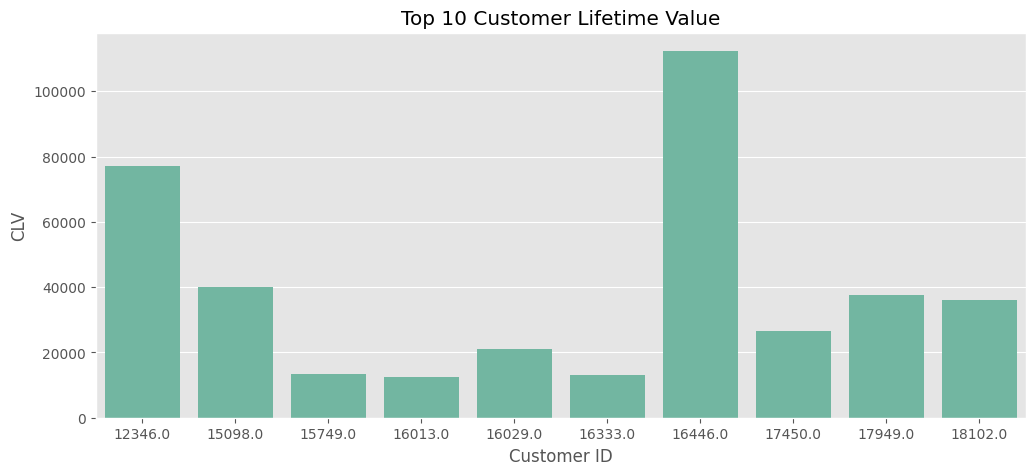

In [18]:
# Visualisasi Top Customer CLV
top_clv = clv.head(10).reset_index()

plt.figure(figsize=(12,5))
sns.barplot(data=top_clv, x="CustomerID", y="CLV")

plt.title("Top 10 Customer Lifetime Value")
plt.xlabel("Customer ID")
plt.ylabel("CLV")

plt.show()


---
## 🏁 Next Steps
1. Tambahkan analisis customer segmentation
2. Tambahkan analisis RFM (Recency, Frequency, Monetary)
3. Tambahkan forecasting sales
4. Simpan notebook sebagai portfolio project
